
Dataset 1
  E (Piecewise Lagrange deg=3): 15977.74 degF*s


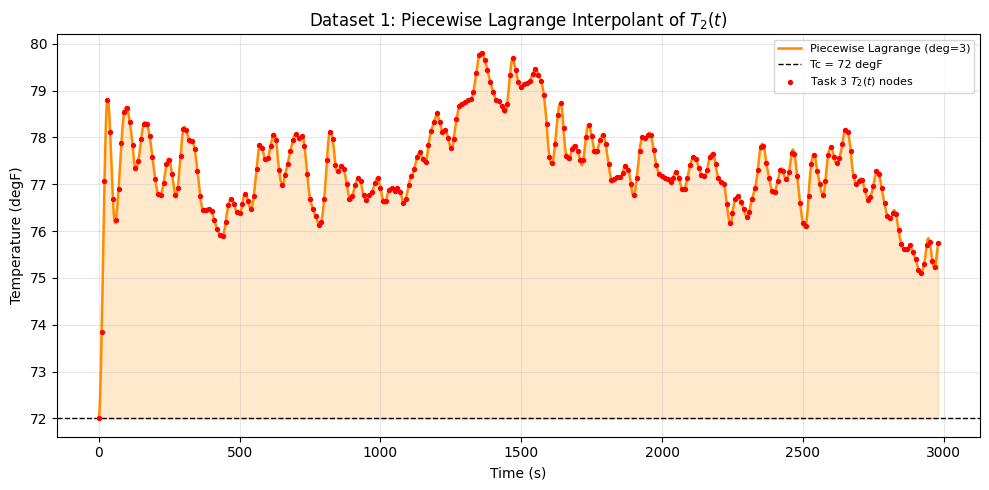


Dataset 2
  E (Piecewise Lagrange deg=3): 31922.07 degF*s


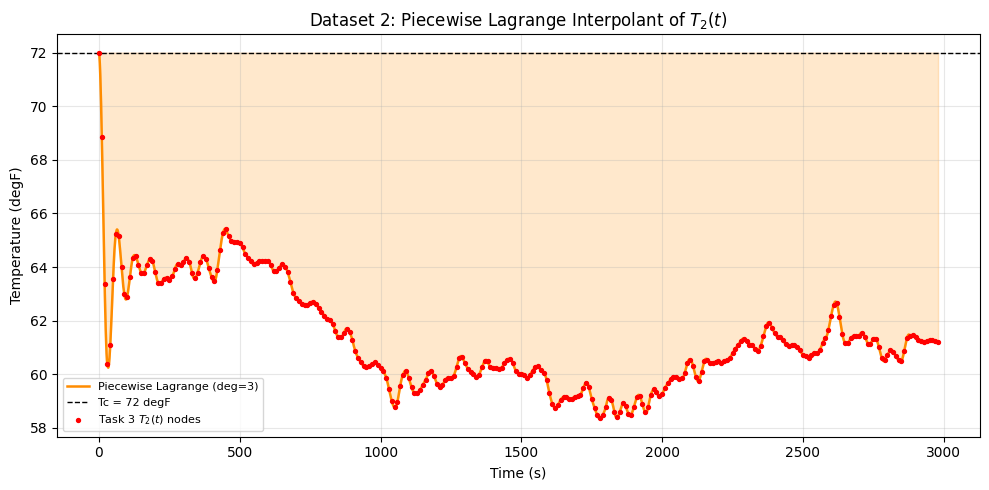


Dataset 3
  E (Piecewise Lagrange deg=3): 24919.12 degF*s


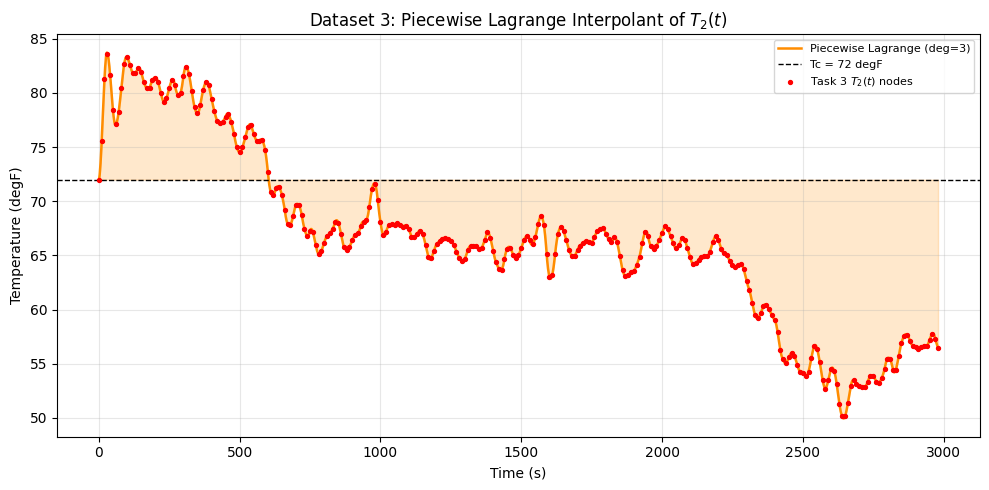

In [12]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def load_task3_definitions(notebook_path='task3.ipynb'):
    """Load Task 3 data and solver definitions without running its plots."""
    notebook = json.loads(Path(notebook_path).read_text(encoding='utf-8'))
    code = '\n'.join(
        ''.join(cell.get('source', []))
        for cell in notebook['cells']
        if cell.get('cell_type') == 'code'
    )
    code = code.split('\nfor theta_data, name in zip(datasets, dataset_names):')[0]
    namespace = {}
    exec(code, namespace)
    return namespace


_task3 = load_task3_definitions()
datasets = _task3['datasets']
dataset_names = _task3['dataset_names']
solve_task3 = _task3['solve_task3']
alpha = _task3['alpha']
k = _task3['k']
dt_data = _task3['dt_data']

Tc = 72.0
h = 1.0
piecewise_degree = 3


def lagrange_basis(t_val, i, t_nodes):
    result = 1.0
    for j in range(len(t_nodes)):
        if j != i:
            result *= (t_val - t_nodes[j]) / (t_nodes[i] - t_nodes[j])
    return result


def lagrange_interpolate(t_val, t_nodes, theta_nodes):
    return sum(
        float(theta_nodes[i]) * lagrange_basis(t_val, i, t_nodes)
        for i in range(len(t_nodes))
    )


def integrate_exposure(t_fine, P_fine):
    """Trapezoid rule on |P(t) - Tc|."""
    trapz = getattr(np, 'trapezoid', np.trapz)
    return trapz(np.abs(P_fine - Tc), t_fine)


def piecewise_lagrange(t_fine, t_nodes, T_nodes, degree=3):
    """Evaluate a piecewise Lagrange interpolant on t_fine."""
    P_fine = np.zeros_like(t_fine)
    n = len(t_nodes)
    seg_size = degree + 1

    for start in range(0, n - 1, degree):
        end = min(start + seg_size, n)
        t_seg = t_nodes[start:end]
        T_seg = T_nodes[start:end]

        if len(t_seg) < 2:
            continue

        if start == 0:
            mask = (t_fine >= t_seg[0]) & (t_fine <= t_seg[-1])
        else:
            mask = (t_fine > t_seg[0]) & (t_fine <= t_seg[-1])

        for idx in np.where(mask)[0]:
            P_fine[idx] = lagrange_interpolate(t_fine[idx], t_seg, T_seg)

    return P_fine


for theta_data, name in zip(datasets, dataset_names):
    print(f"\n{'=' * 55}")
    print(name)
    print(f"{'=' * 55}")

    t_solver, T_solver, _ = solve_task3(theta_data, h=h, alpha=alpha, k=k)

    step = int(dt_data / h)
    t_nodes = t_solver[::step]
    T_nodes = T_solver[::step]
    t_fine = np.linspace(t_nodes[0], t_nodes[-1], 2000)

    T_2 = piecewise_lagrange(
        t_fine,
        t_nodes,
        T_nodes,
        degree=piecewise_degree,
    )
    E_piecewise = integrate_exposure(t_fine, T_2)

    print(f"  E (Piecewise Lagrange deg={piecewise_degree}): {E_piecewise:.2f} degF*s")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        t_fine,
        T_2,
        color='darkorange',
        linewidth=1.8,
        label=f'Piecewise Lagrange (deg={piecewise_degree})',
    )
    ax.fill_between(t_fine, Tc, T_2, alpha=0.2, color='darkorange')
    ax.axhline(Tc, color='black', linestyle='--', linewidth=1, label=f'Tc = {Tc:.0f} degF')
    ax.scatter(t_nodes, T_nodes, color='red', s=8, zorder=5, label=r'Task 3 $T_2(t)$ nodes')
    ax.set_title(f'{name}: Piecewise Lagrange Interpolant of $T_2(t)$')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Temperature (degF)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
